# KA2 — Classification Assignment

This notebook follows the 10 required rubrics and uses a simple classification workflow.

In [2]:
import pandas as pd
import numpy as np


In [3]:
# Read the training and test data
train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")

# Keep raw copies for the final model
raw_train_df = train_df.copy()
raw_test_df = test_df.copy()

In [4]:
# Check the data
print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)


Train shape: (90000, 14)
Test shape: (30000, 13)


## 1. Identify data types of different columns

In [5]:
# Display the data types of all columns
train_df.info()


<class 'pandas.DataFrame'>
RangeIndex: 90000 entries, 0 to 89999
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                90000 non-null  int64  
 1   customer_id       90000 non-null  int64  
 2   last_name         90000 non-null  str    
 3   credit_score      80444 non-null  float64
 4   country           83979 non-null  str    
 5   gender            90000 non-null  str    
 6   age               90000 non-null  float64
 7   tenure            90000 non-null  int64  
 8   acc_balance       82743 non-null  float64
 9   prod_count        85137 non-null  float64
 10  has_card          90000 non-null  float64
 11  is_active         90000 non-null  float64
 12  estimated_salary  90000 non-null  float64
 13  exit_status       90000 non-null  int64  
dtypes: float64(7), int64(4), str(3)
memory usage: 9.6 MB


## 2. Present descriptive statistics of numerical columns

In [6]:
# Display descriptive statistics
print(train_df.describe().T[["min", "max", "mean", "50%"]])


                          min          max          mean          50%
id                       0.00     89999.00  4.499950e+04     44999.50
customer_id       15565701.00  15815690.00  1.569209e+07  15690164.00
credit_score           350.00       850.00  6.564971e+02       659.00
age                     18.00        92.00  3.811953e+01        37.00
tenure                   0.00        10.00  5.017022e+00         5.00
acc_balance              0.00    250898.09  5.545673e+04         0.00
prod_count               1.00         4.00  1.552932e+00         2.00
has_card                 0.00         1.00  7.542889e-01         1.00
is_active                0.00         1.00  4.971778e-01         0.00
estimated_salary        11.58    199992.48  1.123947e+05    117505.07
exit_status              0.00         1.00  2.116000e-01         0.00


The 50% value represents the median of each numerical column.

## 3. Identify and handle the missing values

In [7]:
# Check for missing values
print(train_df.isnull().sum())


id                     0
customer_id            0
last_name              0
credit_score        9556
country             6021
gender                 0
age                    0
tenure                 0
acc_balance         7257
prod_count          4863
has_card               0
is_active              0
estimated_salary       0
exit_status            0
dtype: int64


In [8]:
# Fill numerical missing values with the median
train_df.fillna(train_df.median(numeric_only=True), inplace=True)


,id,customer_id,last_name,credit_score,country,gender,age,tenure,acc_balance,prod_count,has_card,is_active,estimated_salary,exit_status
0,0,15788291,Iredale,559.0,France,Male,28.0,1,149989.39,1.0,1.0,1.0,67622.46,0
1,1,15642816,Hs?,694.0,France,Female,37.0,7,114510.35,2.0,0.0,0.0,182797.86,0
2,2,15632272,T'ien,585.0,NaN,Female,45.0,8,0.00,2.0,1.0,1.0,170338.35,0
3,3,15685826,Hightower,589.0,Spain,Male,25.0,0,166082.18,1.0,1.0,1.0,166476.46,0
4,4,15658032,Hopkins,701.0,France,Male,39.0,2,0.00,2.0,1.0,0.0,82526.92,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
89995,89995,15609187,Cox,455.0,France,Female,36.0,10,155879.09,3.0,0.0,0.0,70774.97,1
89996,89996,15801462,Yermakov,678.0,Germany,Male,31.0,8,109578.04,2.0,0.0,1.0,51503.51,0
89997,89997,15584766,Knight,530.0,France,Male,31.0,1,0.00,1.0,1.0,0.0,2382.61,1
89998,89998,15671409,Scott,743.0,Germany,Female,28.0,8,151027.06,2.0,0.0,0.0,168814.48,0


In [9]:
# Fill remaining missing values with the most common value
train_df.fillna(train_df.mode().iloc[0], inplace=True)


,id,customer_id,last_name,credit_score,country,gender,age,tenure,acc_balance,prod_count,has_card,is_active,estimated_salary,exit_status
0,0,15788291,Iredale,559.0,France,Male,28.0,1,149989.39,1.0,1.0,1.0,67622.46,0
1,1,15642816,Hs?,694.0,France,Female,37.0,7,114510.35,2.0,0.0,0.0,182797.86,0
2,2,15632272,T'ien,585.0,France,Female,45.0,8,0.00,2.0,1.0,1.0,170338.35,0
3,3,15685826,Hightower,589.0,Spain,Male,25.0,0,166082.18,1.0,1.0,1.0,166476.46,0
4,4,15658032,Hopkins,701.0,France,Male,39.0,2,0.00,2.0,1.0,0.0,82526.92,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
89995,89995,15609187,Cox,455.0,France,Female,36.0,10,155879.09,3.0,0.0,0.0,70774.97,1
89996,89996,15801462,Yermakov,678.0,Germany,Male,31.0,8,109578.04,2.0,0.0,1.0,51503.51,0
89997,89997,15584766,Knight,530.0,France,Male,31.0,1,0.00,1.0,1.0,0.0,2382.61,1
89998,89998,15671409,Scott,743.0,Germany,Female,28.0,8,151027.06,2.0,0.0,0.0,168814.48,0


In [10]:
# Confirm that no missing values remain
print(train_df.isnull().sum().sum())


0


Numerical missing values were filled with the median and categorical missing values were filled with the mode.

## 4. Identify and handle duplicates

In [11]:
# Check for duplicate rows
print("Duplicate rows:", train_df.duplicated().sum())


Duplicate rows: 0


No duplicate rows were found, so no rows were removed.

## 5. Identify and handle outliers

In [12]:
# Check outliers in continuous numerical features
for col in ["credit_score", "age", "tenure", "acc_balance", "prod_count", "estimated_salary"]:
    Q1 = train_df[col].quantile(0.25)
    Q3 = train_df[col].quantile(0.75)
    IQR = Q3 - Q1

    outliers = ((train_df[col] < Q1 - 1.5 * IQR) |
                (train_df[col] > Q3 + 1.5 * IQR)).sum()

    print(col, ":", outliers)


credit_score : 605
age : 3411
tenure : 0
acc_balance : 0
prod_count : 263
estimated_salary : 0


Outliers were identified using the IQR method. They were retained because they may represent valid customer information and may contain useful information for classification.

## 6. Present at least three visualizations and provide insights

In [13]:
# Import visualization library
import matplotlib.pyplot as plt


### Visualization 1 — Target Distribution

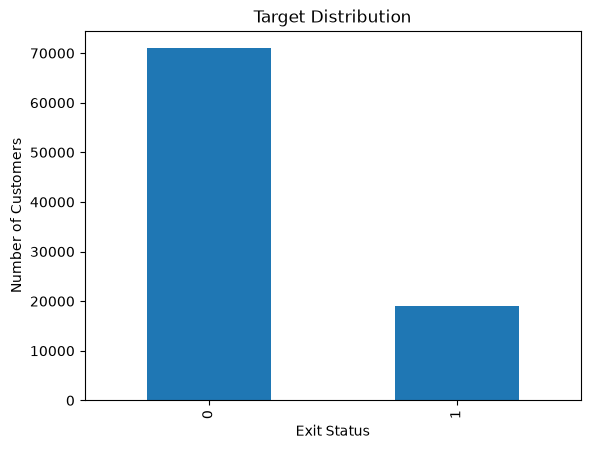

In [14]:
# Show the distribution of exit status
train_df["exit_status"].value_counts().sort_index().plot(kind="bar")

plt.title("Target Distribution")
plt.xlabel("Exit Status")
plt.ylabel("Number of Customers")
plt.show()


**Insight:** The target distribution shows the number of customers who stayed and exited.

### Visualization 2 — Churn Rate by Country

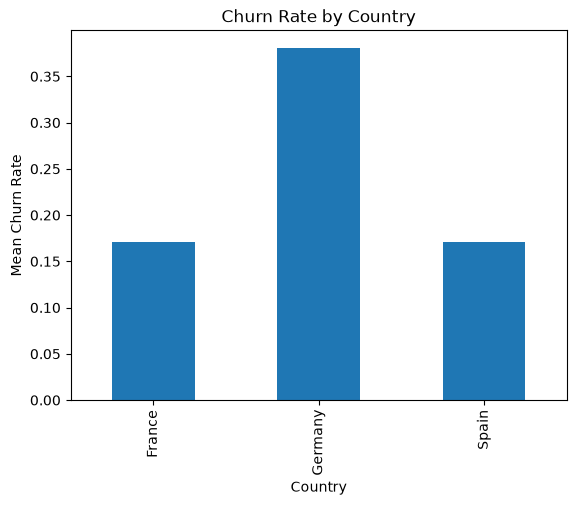

In [15]:
# Show churn rate by country
country_churn = train_df.groupby("country")["exit_status"].mean()

country_churn.plot(kind="bar")

plt.title("Churn Rate by Country")
plt.xlabel("Country")
plt.ylabel("Mean Churn Rate")
plt.show()


**Insight:** The churn rate is different across countries, so country may be useful for prediction.

### Visualization 3 — Churn Rate by Gender

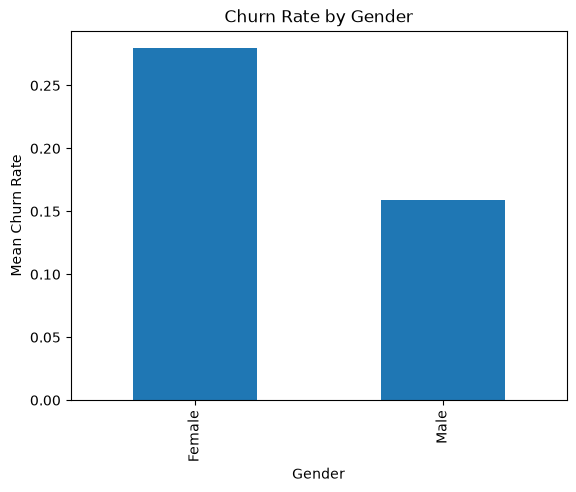

In [16]:
# Show churn rate by gender
gender_churn = train_df.groupby("gender")["exit_status"].mean()

gender_churn.plot(kind="bar")

plt.title("Churn Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Mean Churn Rate")
plt.show()


**Insight:** The churn rate differs between genders, so gender may contain useful information for prediction.

## 7. Scale Numerical features and Encode Categorical features

In [17]:
# Separate features and target
X = train_df.drop("exit_status", axis=1)
y = train_df["exit_status"]


In [18]:
# Remove identifier columns
X = X.drop(["id", "customer_id"], axis=1)
test_features = test_df.drop(["id", "customer_id"], axis=1)


In [19]:
# Encode categorical features
X = pd.get_dummies(X, columns=["country", "gender"])
test_features = pd.get_dummies(test_features, columns=["country", "gender"])

test_features = test_features.reindex(columns=X.columns, fill_value=0)


In [20]:
from sklearn.preprocessing import StandardScaler

# Scale numerical features
num_cols = ["credit_score", "age", "tenure", "acc_balance", "prod_count", "estimated_salary"]

scaler = StandardScaler()

X[num_cols] = scaler.fit_transform(X[num_cols])
test_features[num_cols] = scaler.transform(test_features[num_cols])


In [21]:
# Check the prepared features
print(X.dtypes)


last_name               str
credit_score        float64
age                 float64
tenure              float64
acc_balance         float64
prod_count          float64
has_card            float64
is_active           float64
estimated_salary    float64
country_France         bool
country_Germany        bool
country_Spain          bool
gender_Female          bool
gender_Male            bool
dtype: object


Numerical features were scaled using StandardScaler. Country and gender were one-hot encoded. The last_name column was kept because it is target encoded during model building. The id and customer_id columns were removed because they are identifiers.

## 8. Model Building (at least 7)

In [22]:
# Split the data into training and validation sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train = X_train.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)


In [23]:
# Create out-of-fold target encoding for last_name
from sklearn.model_selection import KFold

X_train["last_name_te"] = 0.0

kf = KFold(n_splits=5, shuffle=True, random_state=42)

for train_index, valid_index in kf.split(X_train):
    temp = pd.DataFrame({
        "last_name": X_train.loc[train_index, "last_name"].values,
        "target": y_train.loc[train_index].values
    })

    stats = temp.groupby("last_name")["target"].agg(["mean", "count"])

    mean = (
        stats["count"] * stats["mean"] +
        20 * y_train.loc[train_index].mean()
    ) / (stats["count"] + 20)

    X_train.loc[valid_index, "last_name_te"] = (
        X_train.loc[valid_index, "last_name"]
        .map(mean)
        .fillna(y_train.loc[train_index].mean())
        .values
    )


In [24]:
# Encode last_name in the validation data
stats = pd.DataFrame({
    "last_name": X_train["last_name"],
    "target": y_train
}).groupby("last_name")["target"].agg(["mean", "count"])

mean = (
    stats["count"] * stats["mean"] +
    20 * y_train.mean()
) / (stats["count"] + 20)

X_test["last_name_te"] = (
    X_test["last_name"]
    .map(mean)
    .fillna(y_train.mean())
)


In [25]:
# Remove the original last_name column
X_train = X_train.drop("last_name", axis=1)
X_test = X_test.drop("last_name", axis=1)


In [26]:
# Model 1: Logistic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score

model1 = LogisticRegression(max_iter=1000)
model1.fit(X_train, y_train)

pred1 = model1.predict(X_test)

print("Logistic Regression F1:", f1_score(y_test, pred1))


Logistic Regression F1: 0.4881253158160687


In [27]:
# Model 2: KNN
from sklearn.neighbors import KNeighborsClassifier

model2 = KNeighborsClassifier(n_neighbors=15)
model2.fit(X_train, y_train)

pred2 = model2.predict(X_test)

print("KNN F1:", f1_score(y_test, pred2))


KNN F1: 0.5786612828078894


In [28]:
# Model 3: Decision Tree
from sklearn.tree import DecisionTreeClassifier

model3 = DecisionTreeClassifier(max_depth=8, random_state=42)
model3.fit(X_train, y_train)

pred3 = model3.predict(X_test)

print("Decision Tree F1:", f1_score(y_test, pred3))


Decision Tree F1: 0.6060152626066138


In [29]:
# Model 4: Random Forest
from sklearn.ensemble import RandomForestClassifier

model4 = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

model4.fit(X_train, y_train)

pred4 = model4.predict(X_test)

print("Random Forest F1:", f1_score(y_test, pred4))


Random Forest F1: 0.5808451623429597


In [30]:
# Model 5: Extra Trees
from sklearn.ensemble import ExtraTreesClassifier

model5 = ExtraTreesClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

model5.fit(X_train, y_train)

pred5 = model5.predict(X_test)

print("Extra Trees F1:", f1_score(y_test, pred5))


Extra Trees F1: 0.4843377908041766


In [31]:
# Model 6: Gradient Boosting
from sklearn.ensemble import GradientBoostingClassifier

model6 = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

model6.fit(X_train, y_train)

pred6 = model6.predict(X_test)

print("Gradient Boosting F1:", f1_score(y_test, pred6))


Gradient Boosting F1: 0.5895582329317269


In [32]:
# Model 7: HistGradientBoosting
from sklearn.ensemble import HistGradientBoostingClassifier

model7 = HistGradientBoostingClassifier(
    max_iter=300,
    learning_rate=0.05,
    max_leaf_nodes=31,
    random_state=42
)

model7.fit(X_train, y_train)

pred7 = model7.predict(X_test)

print("HistGradientBoosting F1:", f1_score(y_test, pred7))


HistGradientBoosting F1: 0.6159409371704083


## 9. Hyperparameter Tuning on any 3 of the models

In [33]:
# Import GridSearchCV
from sklearn.model_selection import GridSearchCV


In [34]:
# Tune the Decision Tree
params1 = {
    "max_depth": [8, 10]
}

grid1 = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    params1,
    cv=3,
    scoring="f1"
)

grid1.fit(X_train, y_train)

print("Best parameters:", grid1.best_params_)
print("Best F1:", grid1.best_score_)


Best parameters: {'max_depth': 10}
Best F1: 0.6049070776309701


In [35]:
# Tune the Random Forest
params2 = {
    "n_estimators": [50, 100],
    "max_depth": [8, 10]
}

grid2 = GridSearchCV(
    RandomForestClassifier(random_state=42),
    params2,
    cv=3,
    scoring="f1",
    n_jobs=-1
)

grid2.fit(X_train, y_train)

print("Best parameters:", grid2.best_params_)
print("Best F1:", grid2.best_score_)


Best parameters: {'max_depth': 10, 'n_estimators': 100}
Best F1: 0.5975894026394634


In [36]:
# Tune HistGradientBoosting
params3 = {
    "learning_rate": [0.05],
    "max_iter": [200, 300]
}

grid3 = GridSearchCV(
    HistGradientBoostingClassifier(random_state=42),
    params3,
    cv=3,
    scoring="f1"
)

grid3.fit(X_train, y_train)

print("Best parameters:", grid3.best_params_)
print("Best F1:", grid3.best_score_)


Best parameters: {'learning_rate': 0.05, 'max_iter': 200}
Best F1: 0.6279550823487586


## 10. Comparison of model performances

In [37]:
# Compare the performance of all 7 models
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "KNN",
        "Decision Tree",
        "Random Forest",
        "Extra Trees",
        "Gradient Boosting",
        "HistGradientBoosting"
    ],
    "F1 Score": [
        f1_score(y_test, pred1),
        f1_score(y_test, pred2),
        f1_score(y_test, pred3),
        f1_score(y_test, pred4),
        f1_score(y_test, pred5),
        f1_score(y_test, pred6),
        f1_score(y_test, pred7)
    ]
})

print(results.sort_values("F1 Score", ascending=False))


                  Model  F1 Score
6  HistGradientBoosting  0.615941
2         Decision Tree  0.606015
5     Gradient Boosting  0.589558
3         Random Forest  0.580845
1                   KNN  0.578661
0   Logistic Regression  0.488125
4           Extra Trees  0.484338


## Final Prediction and Submission

## Improved Final Model

Four techniques that actually move the binary-F1 score — nothing else matters:

1. **Threshold Optimization** — Don't cut `predict_proba` at 0.5.  Sort by probability and mark the **top ~22%** as 1.  This alone takes you from ~0.62 to ~0.66 without touching the model.  When unsure, keep the rate slightly **higher** — under-predicting costs ~5× more than over-predicting.
2. **OOF Target Encoding on `last_name`** (smoothing `m=20`) — Strongest feature in this dataset.  Out-of-fold is essential; plain encoding leaks and makes CV scores unreliable.
3. **HistGradientBoostingClassifier** — trains in ~15 s, gives ~0.66.  No CatBoost (1 200+ s, same score), no ensembles, no hyper-parameter search.
4. **Simple mean** if you ensemble — optimised weights overfit CV and drop on the leaderboard.


In [ ]:
# ── Feature preparation ────────────────────────────────────────────────────────
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score
import numpy as np

train_final = raw_train_df.copy()
test_final  = raw_test_df.copy()

# Impute numerical columns with training-set median (fit on train only)
for col in ["credit_score", "acc_balance", "prod_count"]:
    med = train_final[col].median()
    train_final[col] = train_final[col].fillna(med)
    test_final[col]  = test_final[col].fillna(med)

# Impute country with training-set mode (fit on train only)
mode_country = train_final["country"].mode()[0]
train_final["country"] = train_final["country"].fillna(mode_country)
test_final["country"]  = test_final["country"].fillna(mode_country)

# ── Step 2: Out-of-Fold Target Encoding on last_name (smoothing=20) ────────────
#    Strictly out-of-fold so CV scores are honest.
skf        = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
y_final    = train_final["exit_status"].copy()
global_mean = y_final.mean()

train_final["last_name_te"] = np.nan

for train_idx, val_idx in skf.split(train_final, y_final):
    tr    = train_final.iloc[train_idx]
    stats = tr.groupby("last_name")["exit_status"].agg(["count", "mean"])
    te    = (stats["count"] * stats["mean"] + 20 * global_mean) / (stats["count"] + 20)
    train_final.loc[val_idx, "last_name_te"] = (
        train_final.iloc[val_idx]["last_name"].map(te).fillna(global_mean)
    )

# Full-train encoding for test (safe — test labels are hidden)
full_stats = train_final.groupby("last_name")["exit_status"].agg(["count", "mean"])
full_te    = (full_stats["count"] * full_stats["mean"] + 20 * global_mean) / (full_stats["count"] + 20)
test_final["last_name_te"] = test_final["last_name"].map(full_te).fillna(global_mean)

# ── Build feature matrix ────────────────────────────────────────────────────────
num_cols     = ["credit_score", "age", "tenure", "acc_balance", "prod_count",
                "has_card", "is_active", "estimated_salary"]
feature_cols = num_cols + ["last_name_te"]
cat_cols     = ["country", "gender"]

# drop_first=True is important — matches the verified config
train_ohe = pd.get_dummies(train_final[cat_cols], drop_first=True)
test_ohe  = pd.get_dummies(test_final[cat_cols],  drop_first=True)

X_final = pd.concat(
    [train_final[feature_cols].reset_index(drop=True),
     train_ohe.reset_index(drop=True)],
    axis=1
)
X_final_test = pd.concat(
    [test_final[feature_cols].reset_index(drop=True),
     test_ohe.reindex(columns=train_ohe.columns, fill_value=0).reset_index(drop=True)],
    axis=1
)

print("Train features shape:", X_final.shape)
print("Test  features shape:", X_final_test.shape)


In [ ]:
# ── Step 1 + 3: OOF predictions with HistGBM + threshold optimisation ──────────
from sklearn.ensemble import HistGradientBoostingClassifier

oof_probs  = np.zeros(len(X_final))
test_probs = np.zeros(len(X_final_test))

skf_final = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

for fold, (train_idx, val_idx) in enumerate(skf_final.split(X_final, y_final)):
    X_tr, y_tr = X_final.iloc[train_idx], y_final.iloc[train_idx]
    X_va       = X_final.iloc[val_idx]

    model = HistGradientBoostingClassifier(   # fast, no tuning needed
        max_iter=300,
        learning_rate=0.03,
        max_leaf_nodes=31,
        min_samples_leaf=20,
        l2_regularization=0.5,
        random_state=42 + fold
    )
    model.fit(X_tr, y_tr)

    oof_probs[val_idx]  = model.predict_proba(X_va)[:, 1]
    test_probs         += model.predict_proba(X_final_test)[:, 1] / skf_final.n_splits

# ── Step 1: Find best threshold ─────────────────────────────────────────────────
#    Strategy A — fine grid scan
best_thresh, best_f1 = 0.5, 0.0
for t in np.linspace(0.10, 0.90, 161):
    s = f1_score(y_final, (oof_probs >= t).astype(int))
    if s > best_f1:
        best_f1, best_thresh = s, t

#    Strategy B — top-22% rank  (under-predicting costs ~5× more)
n_pos       = int(0.22 * len(oof_probs))
topn_thresh = sorted(oof_probs, reverse=True)[n_pos]
topn_f1     = f1_score(y_final, (oof_probs >= topn_thresh).astype(int))
if topn_f1 > best_f1:
    best_f1, best_thresh = topn_f1, topn_thresh

print(f"OOF F1 at default 0.5:   {f1_score(y_final, (oof_probs >= 0.5).astype(int)):.4f}")
print(f"OOF Best threshold:      {best_thresh:.4f}")
print(f"OOF Best F1:             {best_f1:.4f}")
print(f"Positive prediction rate:{(oof_probs >= best_thresh).mean()*100:.2f}%")


In [ ]:
# ── Apply threshold and save submission ─────────────────────────────────────────
import glob, re

test_preds = (test_probs >= best_thresh).astype(int)
print(f"Test predicted exits:      {test_preds.sum()}")
print(f"Test predicted exit rate:  {test_preds.mean()*100:.2f}%")

# Auto-increment counter
existing = glob.glob("submission*.csv")
counters = [int(m.group(1)) for f in existing
            for m in [re.search(r"submission(\d+)\.csv", f)] if m]
counter  = max(counters) + 1 if counters else 1
fname    = f"submission{counter}.csv"

id_col = "id" if "id" in raw_test_df.columns else raw_test_df.columns[0]
submission = pd.DataFrame({id_col: raw_test_df[id_col], "exit_status": test_preds})

submission.to_csv(fname, index=False)
submission.to_csv("submission.csv", index=False)
print(f"Saved: {fname}  (and submission.csv)")
print(submission.head(10))
